# This notebook shows how to apply the angular momentum operators Lx, Ly, Lz to wavefunctions
### Import the necessary libraries

In [1]:
%matplotlib inline
import re
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.session import ORBITAL_LABELS

### The angular momentum operator
Restricted to atom $\alpha$'s muffin-tin sphere and angular-momentum channel $\ell$, $L_x,L_y,L_z$ mix $m$ within that $\ell$ shell -- unlike the orbital-projection operator $P_{\alpha,\ell}$, which sums over $m$. elkpy reuses upstream Elk's own `lopzflm` subroutine (the same one Elk's own on-site $\hat{\bf L}\cdot\hat{\bf S}$ trace, `dmatls.f90`, already uses) rather than deriving a new ladder operator:
$$ (L_x+iL_y)Y_{\ell m}=\sqrt{(\ell-m)(\ell+m+1)}\,Y_{\ell,m+1}, \quad (L_x-iL_y)Y_{\ell m}=\sqrt{(\ell+m)(\ell-m+1)}\,Y_{\ell,m-1}, \quad L_zY_{\ell m}=mY_{\ell m} $$
$L_x,L_y,L_z$ are Hermitian, but -- unlike the projection operators -- not positive semi-definite: an angular momentum expectation value can be negative.

In [2]:
# Bohr, monolayer 2H-WSe2 (a=3.32 Angstrom, thickness=3.34 Angstrom, 12 Angstrom vacuum --
# ase.build.mx2(formula="WSe2", kind="2H", a=3.32, thickness=3.34, vacuum=12) converted to Bohr)
A, C = 6.273890733757557, 51.66511224726855
WSE2_AVEC = [(A, 0.0, 0.0), (-A / 2, A * 3 ** 0.5 / 2, 0.0), (0.0, 0.0, C)]
WSE2_SPECIES = {"W": [(0.0, 0.0, 0.5)], "Se": [(2 / 3, 1 / 3, 0.5610826627651793), (2 / 3, 1 / 3, 0.43891733723482085)]}

wse2 = Structure(WSE2_AVEC, WSE2_SPECIES).get_calculation(
    "_scratch/wse2_angmom", xc="PW", ngridk=(3, 3, 1), rgkmax=7.0, spinorb=True
)
wse2.get_energy()  # spin-orbit coupling requires spinpol -- spinorb=True forces it internally

-21010.940270035

### Occupied-band count
From `EIGVAL.OUT`'s own occupation numbers, not an assumed electron count (`spinorb` forces `nspinor=2`, so Elk's own `occmax` is 1.0 per state here, not 2.0).

In [3]:
first_block = (wse2.workdir / "EIGVAL.OUT").read_text().split("k-point")[1]
state_line = re.compile(r"^\s*\d+\s+(\S+)\s+(\S+)\s*$")
occ = [float(m.group(2)) for m in map(state_line.match, first_block.splitlines()) if m]
ist1 = sum(o > 0.5 for o in occ)  # valence-band-top index
ist1

60

### Applying $L_x,L_y,L_z$ to a wavefunction: Hermiticity
Checkable independent of any external reference data -- each matrix is a weighted Gram-type contraction against a Hermitian kernel. `lz_orbital`/`lx_orbital`/`ly_orbital` are resolved by atom and $\ell=0,1,2,3$ (s,p,d,f); `lz`/`lx`/`ly` are their $\ell$-sum, the headline per-atom operator.

In [4]:
w = wse2.structure.atom_index("W")
lm = wse2.get_angular_momentum((0.1, 0.2, 0.0), ist0=ist1 - 3, ist1=ist1 + 3)
for name in ("lx", "ly", "lz"):
    m = getattr(lm, name)[w]
    print(name, "Hermitian:", np.abs(m - m.conj().T).max())

lx Hermitian: 2.8609792490763984e-17
ly Hermitian: 4.163336342344337e-17
lz Hermitian: 5.551115123125783e-17


### Orbital valley locking at K/K' in monolayer WSe2
Xiao, Liu, Feng, Xu & Yao (PRL 108, 196802 (2012)) identify the valence-band-top Bloch state as predominantly tungsten $d_{x^2-y^2}\mp id_{xy}=Y_2^{\mp2}$ -- a PURE $m=\mp2$ state within the d channel, sign tied to the valley. Since $L_z$'s operator norm on $\ell=2$ is $2$, this predicts $|L_z^{(d)}|=2\times$ (W's own d-orbital weight, from `get_orbital_projection()`) exactly -- not merely a nonzero value -- alongside the sign flip $L_z(K)=-L_z(K')$. Below, the same effect is shown as a full band structure colored by $\langle L_z\rangle$ on the W d-channel, not just the two valence-top numbers.

In [5]:
d = ORBITAL_LABELS.index("d")
K, Kprime = (1 / 3, 1 / 3, 0), (-1 / 3, -1 / 3, 0)

with wse2.eigenstate_session() as session:
    lz_k = session.angular_momentum(K, ist1, ist1).lz_orbital[w, d, 0, 0].real
    lz_kprime = session.angular_momentum(Kprime, ist1, ist1).lz_orbital[w, d, 0, 0].real
    d_weight_k = session.orbital_projection(K, ist1, ist1).matrices[w, d, 0, 0].real

print("Lz(K) =", lz_k, " Lz(K') =", lz_kprime)
print("2 * d-weight(K) =", 2 * d_weight_k, " (matches |Lz(K)| -- a PURE m=-2 state, not a mixture)")

Lz(K) = -1.137996416497145  Lz(K') = 1.1379964014478723
2 * d-weight(K) = 1.1379964165000884  (matches |Lz(K)| -- a PURE m=-2 state, not a mixture)


In [6]:
def segment(a, b, n):
    a, b = np.array(a), np.array(b)
    return [tuple(a + (b - a) * t) for t in np.linspace(0, 1, n)]

G, M = (0, 0, 0), (0.5, 0, 0)
# K' as the periodic image (2/3, -1/3, 0) -- same physical point as Kprime above,
# chosen here so the path hugs the BZ boundary the whole way instead of cutting
# through the interior near Gamma (same choice as 07_quantum_geometry.ipynb)
Kp = (2 / 3, -1 / 3, 0)
segments = [segment(G, K, 7)] + [segment(a, b, 7)[1:] for a, b in [(K, M), (M, Kp), (Kp, G)]]
ticks = np.concatenate([[0], np.cumsum([len(s) for s in segments]) - 1])
path = sum(segments, [])

w0, w1 = ist1 - 3, ist1 + 3  # same band window as the Hermiticity check above
efermi = float((wse2.workdir / "EFERMI.OUT").read_text().split()[0])
ha = 27.211386  # Hartree -> eV

energies, lz = [], []
with wse2.eigenstate_session() as session:
    for k in path:
        energies.append(session.get_eigenstates(k).energies[w0 - 1 : w1])
        lz.append(session.angular_momentum(k, w0, w1).lz_orbital[w, d].diagonal().real)
energies = (np.array(energies) - efermi) * ha
lz = np.array(lz)

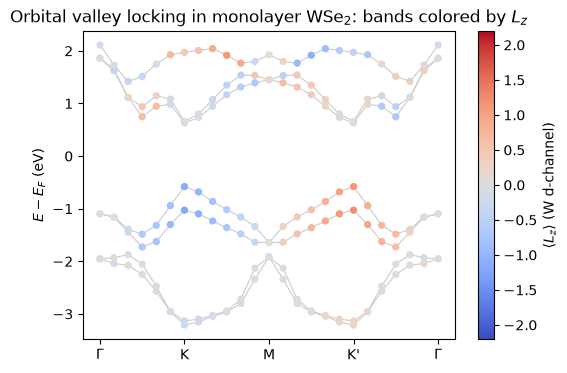

In [7]:
x = np.arange(len(path))
fig, ax = plt.subplots(figsize=(6, 4))
for band in range(energies.shape[1]):
    ax.plot(x, energies[:, band], color="0.8", linewidth=0.8, zorder=1)
sc = ax.scatter(
    np.tile(x, energies.shape[1]), energies.T.ravel(), c=lz.T.ravel(),
    cmap="coolwarm", vmin=-2.2, vmax=2.2, s=18, zorder=2,
)
ax.set_xticks(ticks)
ax.set_xticklabels([r"$\Gamma$", "K", "M", "K'", r"$\Gamma$"])
ax.set_ylabel(r"$E-E_F$ (eV)")
fig.colorbar(sc, ax=ax, label=r"$\langle L_z\rangle$ (W d-channel)")
ax.set_title("Orbital valley locking in monolayer WSe$_2$: bands colored by $L_z$")
plt.show()